## 08 RA/OA ECM-Cell Data Preparation

**What this notebook does:**  
Prepares RA/OA synovial tissue data for the `spatioev.tl` ECM-cell analysis API. It:
1. Loads cell metadata from `data/RA_OA/tmp6.h5ad` (obs-only, memory-efficient)
2. Loads all ECM fiber tables and applies coordinate corrections
3. Calls **`sv.tl.build_cell_fiber_links`** to build a reusable cell-fiber proximity table
4. Calls **`sv.tl.build_nearest_cell_fiber_map`** for fast nearest-fiber lookup

**sv.tl functions demonstrated:**
- `build_cell_fiber_links` — create a long cell × fiber table within a radius
- `build_nearest_cell_fiber_map` — map each cell to its single nearest fiber per type

**Run before:** nothing  
**Must run before:** `08_RA_OA_ECM_cell_05_chp_density_micro_holes_col6_dark_zone_segmentation.ipynb`, `09_RA_OA_ECM_cell_spatioev_module_paper_applications.ipynb`


In [1]:
from pathlib import Path
# DATA AVAILABILITY CHECK
import os
# RA/OA ECM analysis requires the following files
_data_dir = Path.cwd().parent / "data" / "RA_OA" if Path.cwd().name == "notebooks" else Path.cwd() / "data" / "RA_OA"
_required_files = [
    _data_dir / "tmp6.h5ad",
    _data_dir,
]
_missing = [f for f in _required_files if not os.path.exists(f)]
if _missing:
    print(f'Missing required data files: {_missing}')
    print('   This notebook requires real experimental data to run.')
    print('   The code is shown for reference.')
else:
    print('All required data files found. Notebook is ready to run.')


All required data files found. Notebook is ready to run.


# RA/OA ECM-cell data preparation

This notebook prepares the RA/OA cell and ECM fiber data for the `spatioev.tl` ECM-cell analysis modules.

It does four things:

1. Load the cell metadata from `data/RA_OA/tmp6.h5ad` without loading the full expression matrix into memory.
2. Load all ECM fiber object tables from the six sample folders.
3. Apply the JRP141 FOV coordinate correction used in the original combined analysis notebook.
4. Build a reusable cell-fiber link table for downstream proximity, Ripley's K, Moran's I, and graph analyses.

The link table can be expensive to build, so this notebook saves it once and the paper-guided analysis notebook reuses it.

In [2]:
%matplotlib inline

import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba")

from pathlib import Path

import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spatioev as sv
from IPython.display import display

# ── Nature/Cell publication rcParams ─────────────────────────────────────────
_pub_rc = {
    "font.family": "sans-serif", "font.sans-serif": ["Arial","Helvetica","DejaVu Sans"],
    "font.size": 7, "axes.titlesize": 8, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.facecolor": "white", "figure.facecolor": "white",
    "savefig.dpi": 300, "savefig.bbox": "tight",
    "pdf.fonttype": 42, "ps.fonttype": 42,
}
mpl.rcParams.update(_pub_rc)

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR    = PROJECT_ROOT / "data" / "RA_OA"
RESULTS_DIR = PROJECT_ROOT / "notebooks" / "results" / "ra_oa_ecm_cell"
FIGURES_DIR = RESULTS_DIR / "figures" / "00_prepare_links"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ADATA_PATH  = DATA_DIR / "tmp6.h5ad"
FIBER_GLOB  = "*/ark_wdir/fiber_segmentation_processed_data_*/fiber_object_table.csv"

# ── Constants ─────────────────────────────────────────────────────────────────
PIXEL_SIZE_UM  = 0.325
LINK_RADIUS_UM = 50
LINK_RADIUS_PX = LINK_RADIUS_UM / PIXEL_SIZE_UM
IMAGE_KEY      = "imageid"
FOV_KEY        = "fov"
PHENOTYPE_KEY  = "phenotype"
GROUP_KEY      = "pathology"

# Set to a short list such as ["JRP112"] for a small smoke test.
SAMPLE_IDS = None

print("Project root:", PROJECT_ROOT)
print("Link radius:", LINK_RADIUS_UM, "µm =", round(LINK_RADIUS_PX, 2), "px")
print("sv version:", sv.__version__)


Project root: /Users/shihongwu/SpatioEv
Link radius: 50 µm = 153.85 px
sv version: 0.1.0


In [3]:
# ── ECM-cell link functions via sv.tl ────────────────────────────────────────
# [reason] build_cell_fiber_links and build_nearest_cell_fiber_map are fully
# exported from spatioev.tl — no file-path import hack needed.
from spatioev.tl import build_cell_fiber_links, build_nearest_cell_fiber_map

print("ECM link functions imported from sv.tl.")
print("  build_cell_fiber_links:", build_cell_fiber_links)
print("  build_nearest_cell_fiber_map:", build_nearest_cell_fiber_map)


ECM link functions imported from sv.tl.
  build_cell_fiber_links: <function build_cell_fiber_links at 0x3698cdc60>
  build_nearest_cell_fiber_map: <function build_nearest_cell_fiber_map at 0x3698cde40>


In [4]:
# ── Load cell metadata ───────────────────────────────────────────────────────
# [reason] ad.read_h5ad with backed="r" reads only metadata without loading
# the full expression matrix into RAM — essential for large tissue datasets.
import anndata as ad
_backed = ad.read_h5ad(ADATA_PATH, backed="r")
adata_obs = _backed.obs.copy()
_backed.file.close()

# Wrap in a lightweight AnnData so downstream sv.tl functions work unchanged
adata = ad.AnnData(obs=adata_obs)

if SAMPLE_IDS is not None:
    keep = adata.obs[IMAGE_KEY].isin(SAMPLE_IDS)
    adata = adata[keep].copy()
    print(f"Filtered to {SAMPLE_IDS}: {adata.n_obs} cells")

print("Cells:", adata.n_obs)
print("Cell metadata columns:", len(adata.obs.columns))
display(adata.obs[[IMAGE_KEY, FOV_KEY, PHENOTYPE_KEY, GROUP_KEY,
                    "X_centroid", "Y_centroid"]].head())


Cells: 662388
Cell metadata columns: 90


,imageid,fov,phenotype,pathology,X_centroid,Y_centroid
JRP112_0,JRP112,fov0,Other Immune cells,RA,13100.311872,185.782437
JRP112_1,JRP112,fov0,Non-immune cells,RA,14070.780340,467.928398
JRP112_2,JRP112,fov0,Other Immune cells,RA,14004.151738,487.922460
JRP112_3,JRP112,fov0,Non-immune cells,RA,14098.755780,515.580925
JRP112_4,JRP112,fov0,Other Immune cells,RA,14141.346939,517.469388


,imageid,pathology,n_cells,n_fovs
0,JRP112,RA,53984,1
1,JRP122,RA,70372,1
2,JRP141,RA,227688,4
3,JRP144,OA,61362,1
4,S00292623,OA,162517,1
5,S00293087,OA,86465,1


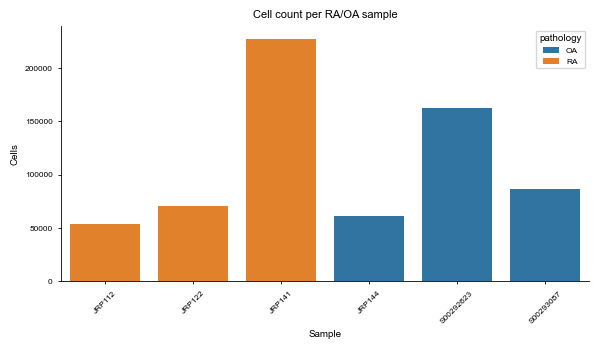

In [5]:
def mode_or_nan(values):
    values = values.dropna()
    if values.empty:
        return np.nan
    return values.mode().iloc[0]

sample_metadata = (
    adata.obs
    .groupby(IMAGE_KEY, observed=True)
    .agg(
        pathology=(GROUP_KEY, mode_or_nan),
        n_cells=(IMAGE_KEY, "size"),
        n_fovs=(FOV_KEY, "nunique"),
    )
    .reset_index()
)

display(sample_metadata)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(data=sample_metadata, x=IMAGE_KEY, y="n_cells", hue="pathology", dodge=False, ax=ax)
ax.set_title("Cell count per RA/OA sample")
ax.set_xlabel("Sample")
ax.set_ylabel("Cells")
ax.tick_params(axis="x", rotation=45)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cell_counts_by_sample.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
def apply_known_fiber_coordinate_corrections(fiber_df):
    """Apply sample-specific coordinate stitching inherited from the legacy notebook."""
    fiber_df = fiber_df.copy()

    is_jrp141 = fiber_df[IMAGE_KEY].eq("JRP141")
    fiber_df.loc[is_jrp141 & fiber_df[FOV_KEY].eq("fov1"), "X_centroid"] += 25818
    fiber_df.loc[is_jrp141 & fiber_df[FOV_KEY].eq("fov2"), "Y_centroid"] += 24880
    fiber_df.loc[is_jrp141 & fiber_df[FOV_KEY].eq("fov3"), "X_centroid"] += 25818
    fiber_df.loc[is_jrp141 & fiber_df[FOV_KEY].eq("fov3"), "Y_centroid"] += 24880

    return fiber_df


def load_ra_oa_fibers(data_dir, sample_ids=None):
    rows = []
    for csv_path in sorted(data_dir.glob(FIBER_GLOB)):
        sample_id = csv_path.parents[2].name
        if sample_ids is not None and sample_id not in sample_ids:
            continue

        fiber_type = csv_path.parent.name.replace("fiber_segmentation_processed_data_", "")
        df = pd.read_csv(csv_path)
        df[IMAGE_KEY] = sample_id
        df["fiber_type"] = fiber_type
        rows.append(df)

    if not rows:
        raise FileNotFoundError(f"No fiber CSVs found under {data_dir}")

    fiber_df = pd.concat(rows, ignore_index=True)
    fiber_df = fiber_df.rename(columns={"centroid-0": "Y_centroid", "centroid-1": "X_centroid"})
    fiber_df = apply_known_fiber_coordinate_corrections(fiber_df)

    # Keep rows with valid coordinates. Do not drop all NaNs globally because some
    # features, such as alignment_score, can be missing for otherwise valid fibers.
    valid_coords = fiber_df[["X_centroid", "Y_centroid"]].notna().all(axis=1)
    fiber_df = fiber_df.loc[valid_coords].copy()

    sample_to_pathology = sample_metadata.set_index(IMAGE_KEY)["pathology"]
    fiber_df[GROUP_KEY] = fiber_df[IMAGE_KEY].map(sample_to_pathology)

    fiber_df["fiber_id"] = [
        f"{img}__{ft}__{fov}__{label}__{i}"
        for i, (img, ft, fov, label) in enumerate(
            zip(fiber_df[IMAGE_KEY], fiber_df["fiber_type"], fiber_df[FOV_KEY], fiber_df["label"])
        )
    ]
    fiber_df = fiber_df.set_index("fiber_id", drop=True)
    return fiber_df


fiber_df = load_ra_oa_fibers(DATA_DIR, sample_ids=SAMPLE_IDS)
print("Fibers:", fiber_df.shape)
display(fiber_df.head())

Fibers: (548442, 14)


,fov,label,Y_centroid,X_centroid,major_axis_length,minor_axis_length,orientation,area,eccentricity,euler_number,alignment_score,imageid,fiber_type,pathology
fiber_id,,,,,,,,,,,,,,
JRP112__CHP__fov0__1__0,fov0,1,2227.188800,13274.571421,3102.901165,956.840093,-0.460731,483183,0.951267,-175,0.299763,JRP112,CHP,RA
JRP112__CHP__fov0__3__1,fov0,3,666.513778,13953.946667,59.774530,56.094354,0.076503,1125,0.345463,0,NaN,JRP112,CHP,RA
JRP112__CHP__fov0__4__2,fov0,4,821.755508,13900.070991,177.843904,80.161325,-0.906514,3268,0.892655,0,0.423132,JRP112,CHP,RA
JRP112__CHP__fov0__5__3,fov0,5,950.569948,13993.943005,20.582604,12.575090,1.509989,193,0.791664,1,NaN,JRP112,CHP,RA
JRP112__CHP__fov0__6__4,fov0,6,1106.382937,13722.457143,115.062281,71.771887,1.413903,2520,0.781612,0,NaN,JRP112,CHP,RA


,imageid,pathology,fiber_type,n_fibers,x_min,x_max,y_min,y_max
0,JRP112,RA,CHP,2727,1056.434564,18173.250000,666.513778,17707.461905
1,JRP112,RA,COL1A1bis,6085,1166.712121,17915.595190,477.931737,17694.026967
2,JRP112,RA,COL4A1,1313,1361.767857,17360.324742,895.841841,18427.136778
3,JRP112,RA,COL6A1,8053,973.143521,17876.228009,519.302676,17759.400922
4,JRP112,RA,FN,7843,941.752011,17967.392320,568.957619,18501.804762
5,JRP112,RA,MFAP5,3717,1150.261261,17689.714829,449.372263,17245.837634
6,JRP122,RA,CHP,6262,1872.258706,12774.769716,1148.101266,19736.602119
7,JRP122,RA,COL1A1bis,2683,656.744939,12605.301887,1287.592432,19589.767773
8,JRP122,RA,COL4A1,904,2110.498452,12393.997225,1495.174721,19518.755656
9,JRP122,RA,COL6A1,10614,496.669065,12868.267857,1107.325785,20028.100559


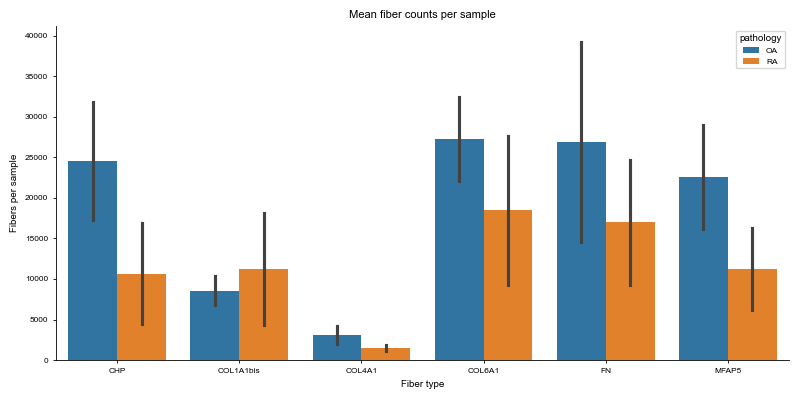

Saved fiber table and summaries to /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell


In [7]:
fiber_summary = (
    fiber_df
    .groupby([IMAGE_KEY, GROUP_KEY, "fiber_type"], observed=True)
    .agg(
        n_fibers=("label", "size"),
        x_min=("X_centroid", "min"),
        x_max=("X_centroid", "max"),
        y_min=("Y_centroid", "min"),
        y_max=("Y_centroid", "max"),
    )
    .reset_index()
)

display(fiber_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=fiber_summary, x="fiber_type", y="n_fibers", hue=GROUP_KEY, estimator="mean", errorbar="se", ax=ax)
ax.set_title("Mean fiber counts per sample")
ax.set_xlabel("Fiber type")
ax.set_ylabel("Fibers per sample")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fiber_counts_by_type_pathology.png", dpi=300, bbox_inches="tight")
plt.show()

fiber_df.to_pickle(RESULTS_DIR / "ra_oa_fiber_df.pkl")
sample_metadata.to_csv(RESULTS_DIR / "ra_oa_sample_metadata.csv", index=False)
fiber_summary.to_csv(RESULTS_DIR / "ra_oa_fiber_summary.csv", index=False)
print("Saved fiber table and summaries to", RESULTS_DIR)

## Build reusable cell-fiber links

`build_cell_fiber_links` creates a long table with `imageid`, `cell_id`, `fiber_id`, and `distance`.

The `radius` must be at least as large as the largest scale you want to analyze with cell-ECM Ripley's K. Larger radii are more biologically inclusive but can produce very large link tables, so start with a smaller sample or smaller radius when testing.

In [8]:
# ── Build cell-fiber links ──────────────────────────────────────────────────
# [reason] For each cell, record every fiber within LINK_RADIUS_UM (50 µm).
# This long table is the input for all downstream ECM-cell statistics.
links_df = build_cell_fiber_links(
    adata,
    fiber_df,
    radius=LINK_RADIUS_PX,
    cell_x="X_centroid",
    cell_y="Y_centroid",
    fiber_x="X_centroid",
    fiber_y="Y_centroid",
    image_key=IMAGE_KEY,
    fiber_image_key=IMAGE_KEY,
)

print("Links:", links_df.shape)
display(links_df.head())
links_df.to_pickle(RESULTS_DIR / "ra_oa_cell_fiber_links.pkl")
print("Saved links to", RESULTS_DIR / "ra_oa_cell_fiber_links.pkl")

Links: (22495433, 4)


,imageid,cell_id,fiber_id,distance
0,JRP112,JRP112_408,JRP112__CHP__fov0__1__0,115.538755
1,JRP112,JRP112_405,JRP112__CHP__fov0__1__0,100.193040
2,JRP112,JRP112_421,JRP112__CHP__fov0__1__0,121.458694
3,JRP112,JRP112_416,JRP112__CHP__fov0__1__0,101.447496
4,JRP112,JRP112_423,JRP112__CHP__fov0__1__0,104.829669


Saved links to /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/ra_oa_cell_fiber_links.pkl


## Build nearest-cell-fiber map

`sv.tl.build_nearest_cell_fiber_map` returns, for each cell, the **single** nearest fiber
of each type and its distance. It is faster than the full link table and sufficient when
you only need the closest fiber per type.

**Biological use:** a nearest-fiber map is the input for `cell_to_fiber_distance` analyses.


In [9]:
# ── Nearest-fiber map (per cell, per fiber type) ─────────────────────────────
# [reason] build_nearest_cell_fiber_map is more efficient than the full link
# table when analyses only need the single closest fiber (distance, COL6/CHP
# proximity tests). It is saved separately from the full link table.
# build_nearest_cell_fiber_map finds the single closest fiber for each cell
# across ALL fiber types pooled (does not accept fiber_type_key — filter fiber_df
# per type before calling, or use links_df for per-type nearest distance).
nearest_df = build_nearest_cell_fiber_map(
    adata,
    fiber_df,
    cell_x="X_centroid",
    cell_y="Y_centroid",
    fiber_x="X_centroid",
    fiber_y="Y_centroid",
    image_key=IMAGE_KEY,
    fiber_image_key=IMAGE_KEY,
)
print("Nearest-fiber map:", nearest_df.shape)
display(nearest_df.head())
nearest_df.to_pickle(RESULTS_DIR / "ra_oa_nearest_cell_fiber_map.pkl")
print("Saved:", RESULTS_DIR / "ra_oa_nearest_cell_fiber_map.pkl")


Nearest-fiber map: (662388, 4)


,imageid,cell_id,fiber_id,distance
0,JRP112,JRP112_0,JRP112__COL6A1__fov0__9__10132,813.245103
1,JRP112,JRP112_1,JRP112__COL1A1bis__fov0__2__2728,26.476897
2,JRP112,JRP112_2,JRP112__MFAP5__fov0__3__26023,32.516854
3,JRP112,JRP112_3,JRP112__MFAP5__fov0__2__26022,50.940170
4,JRP112,JRP112_4,JRP112__COL1A1bis__fov0__1__2727,19.535903


Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/ra_oa_nearest_cell_fiber_map.pkl


,imageid,pathology,phenotype,fiber_type,n_links,median_distance_px,mean_distance_px,median_distance_um,mean_distance_um
0,JRP112,RA,B cells,CHP,2336,104.991796,99.293478,34.122334,32.270380
1,JRP112,RA,B cells,COL1A1bis,3222,109.529837,103.230866,35.597197,33.550032
2,JRP112,RA,B cells,COL4A1,829,110.667516,105.577913,35.966943,34.312822
3,JRP112,RA,B cells,COL6A1,5115,108.108225,101.946323,35.135173,33.132555
4,JRP112,RA,B cells,FN,6048,108.442345,102.491987,35.243762,33.309896


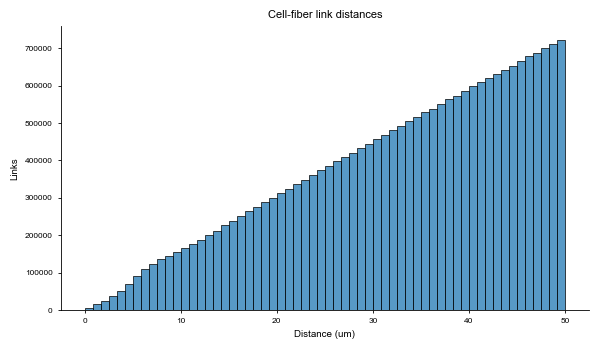

In [10]:
link_summary = (
    links_df
    .merge(fiber_df[["fiber_type"]], left_on="fiber_id", right_index=True, how="left")
    .merge(adata.obs[[PHENOTYPE_KEY, GROUP_KEY]], left_on="cell_id", right_index=True, how="left")
    .groupby([IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY, "fiber_type"], observed=True)
    .agg(
        n_links=("distance", "size"),
        median_distance_px=("distance", "median"),
        mean_distance_px=("distance", "mean"),
    )
    .reset_index()
)
link_summary["median_distance_um"] = link_summary["median_distance_px"] * PIXEL_SIZE_UM
link_summary["mean_distance_um"] = link_summary["mean_distance_px"] * PIXEL_SIZE_UM

display(link_summary.head())
link_summary.to_csv(RESULTS_DIR / "ra_oa_link_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.histplot(links_df["distance"] * PIXEL_SIZE_UM, bins=60, ax=ax)
ax.set_title("Cell-fiber link distances")
ax.set_xlabel("Distance (um)")
ax.set_ylabel("Links")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "link_distance_histogram.png", dpi=300, bbox_inches="tight")
plt.show()